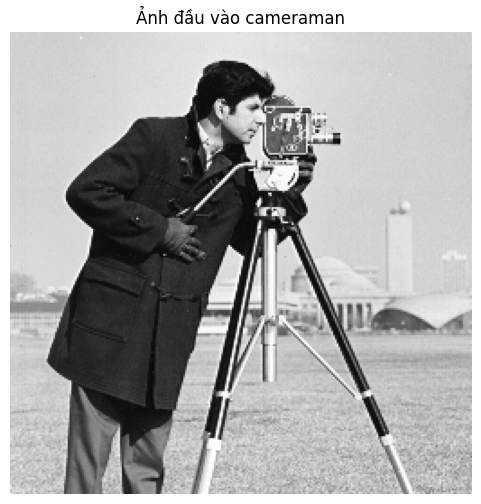

Số góc Harris phát hiện được: 131


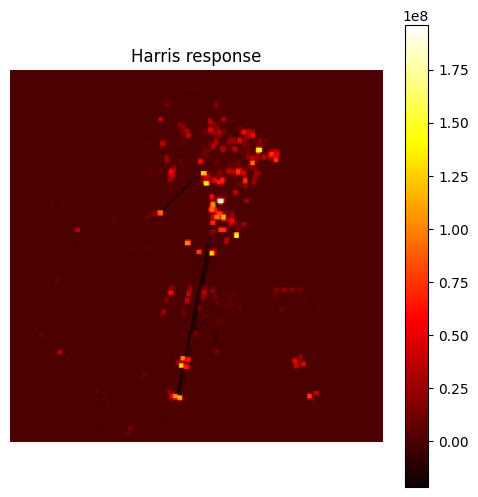

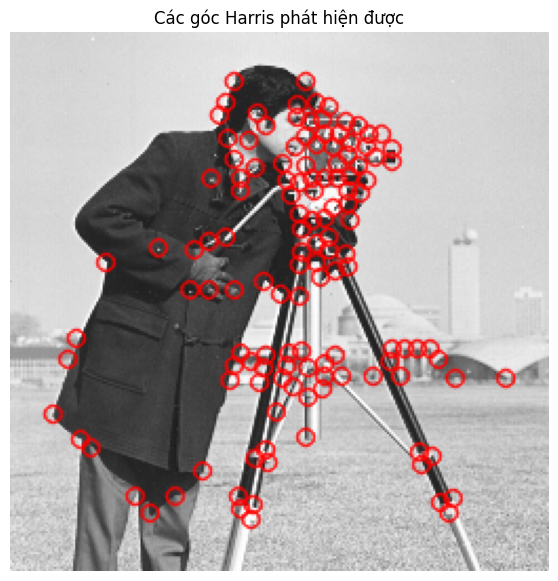

Số keypoint hợp lệ để tính SIFT: 131
Kích thước ma trận đặc trưng F_SIFT: (131, 128)
Kích thước mỗi vector SIFT: 128

Vector SIFT của keypoint đầu tiên:
[ 46.  31.  19.  37.   5.   9.  27.  53.  78.  69.  29.  19.  32.  31.
  25.  23.  14.   8.  13.  17.  23.  32. 108.  38.  26.  15.  19.  32.
  57.  38.  39.  23.  21.  21.  17.  69.  15.   4.   3.  25. 108. 108.
  84.  13.   8.  12.  24.  21.  11.  49. 108.  85.  25.   6.  28.  22.
  60.  18.  24. 108.  60.   7.   9.  84.  17.   3.   2.  11.  20.   5.
   1.   6.  99.  65.  53.  15.  26.  34.  52.  41.  10.  42. 108.  40.
  40.  66.  93.  15. 108.  63.  17.  16.  14.  13.   3.  64.  16.   1.
   0.  13.  14.   3.   2.   6. 101.  28.  24.  16.  37.  20.  30.  49.
  23.  51.  52.  19.  67.  56.  56.  40.  77.  36.   3.   3.  12.  14.
  10.  80.]
Số keypoint hợp lệ để tính HOG: 131
Kích thước ma trận đặc trưng F_HOG: (131, 324)
Kích thước mỗi vector HOG: 324

Vector HOG của keypoint đầu tiên:
[0.2675645  0.02734849 0.03311441 0.06443848 0.

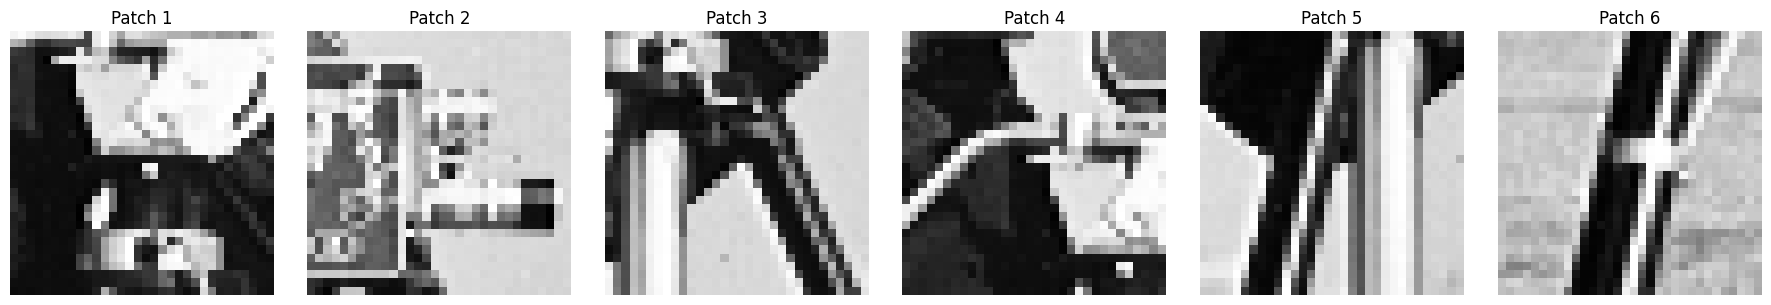

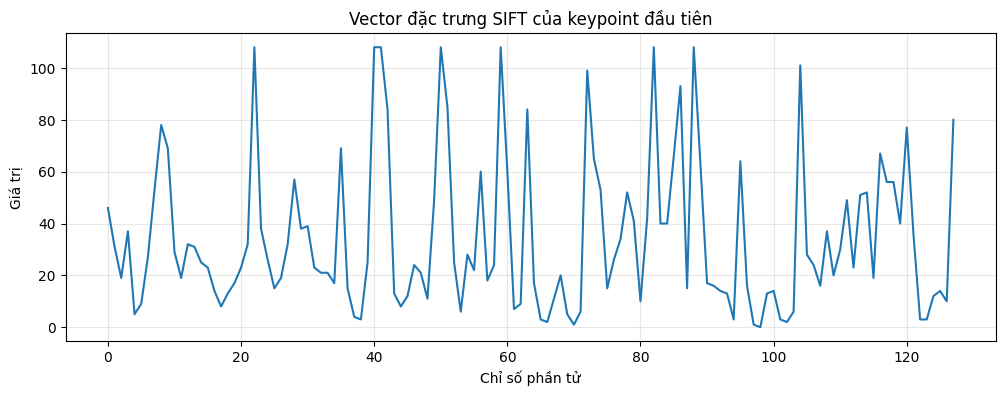

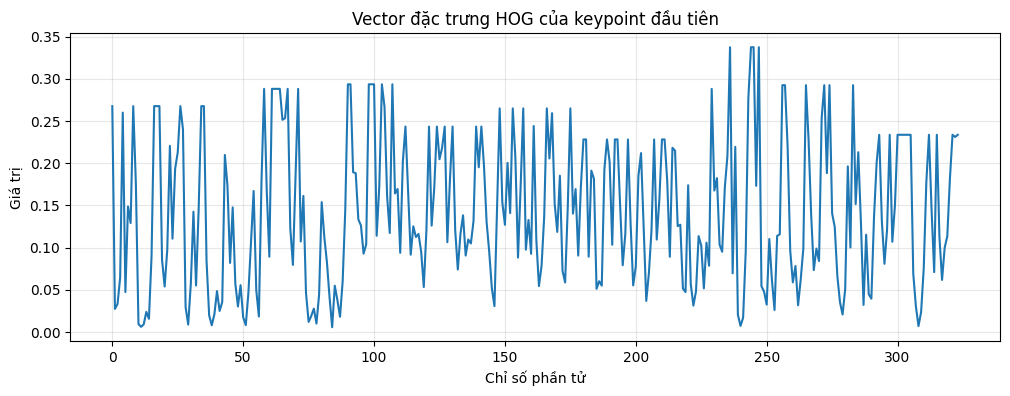

Kiểm tra hoàn tất: chương trình chạy đúng với dữ liệu đầu vào hiện tại.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÁT HIỆN GÓC HARRIS VÀ MÔ TẢ ĐẶC TRƯNG SIFT, HOG
# Chương/Mục liên quan: Chương 5 - Đặc trưng thủ công
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa quy trình phát hiện điểm đặc trưng bằng Harris.
# - Tính vector mô tả SIFT tại các keypoint Harris.
# - Tính vector mô tả HOG trên các patch quanh keypoint Harris.
# - Giúp người học quan sát mối liên hệ giữa điểm đặc trưng và vector mô tả.

# Sau khi chạy code, người học cần:
# 1. Quan sát được các góc Harris trên ảnh đầu vào.
# 2. Hiểu được rằng keypoint và descriptor là hai khái niệm khác nhau.
# 3. Biết cách kiểm tra kích thước vector đặc trưng SIFT và HOG.
# 4. Biết thay đổi tham số để quan sát ảnh hưởng đến số lượng keypoint và descriptor.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman từ GitHub.
# - Kiểu dữ liệu: ảnh mức xám.

# Output:
# - Ảnh gốc.
# - Bản đồ đáp ứng Harris.
# - Ảnh có vẽ các keypoint Harris.
# - Một số patch dùng để tính HOG.
# - Vector đặc trưng SIFT và HOG của keypoint đầu tiên.
# - Đồ thị biểu diễn vector SIFT và HOG đầu tiên.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen


# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_image_gray_from_url(image_url):
    response = urlopen(image_url)
    image_data = np.asarray(bytearray(response.read()), dtype=np.uint8)
    I_gray = cv2.imdecode(image_data, cv2.IMREAD_GRAYSCALE)

    if I_gray is None:
        raise ValueError("Không đọc được ảnh từ URL.")

    return I_gray


image_url = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"

I_gray = read_image_gray_from_url(image_url)


# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(6, 6))
plt.imshow(I_gray, cmap="gray")
plt.title("Ảnh đầu vào cameraman")
plt.axis("off")
plt.show()


# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def detect_harris_keypoints(
    I_gray,
    block_size=2,
    ksize=3,
    k=0.04,
    response_ratio=0.01,
    max_keypoints=300,
    min_distance=6.0,
    border_size=16
):
    I_gray_f = np.float32(I_gray)

    # Tính đáp ứng Harris tại mỗi điểm ảnh.
    # Dòng lệnh này là phần cài đặt chính của thuật toán Harris.
    R_harris = cv2.cornerHarris(
        I_gray_f,
        blockSize=block_size,
        ksize=ksize,
        k=k
    )

    R_harris = cv2.dilate(R_harris, None)

    # Ngưỡng hóa đáp ứng Harris để chọn các điểm ứng viên.
    threshold_value = response_ratio * R_harris.max()

    y_coords, x_coords = np.where(R_harris > threshold_value)

    candidate_keypoints = []
    H, W = I_gray.shape

    for x, y in zip(x_coords, y_coords):
        if x < border_size or x >= W - border_size:
            continue
        if y < border_size or y >= H - border_size:
            continue

        response_value = float(R_harris[y, x])

        keypoint = cv2.KeyPoint(
            float(x),
            float(y),
            8.0,
            -1,
            response_value
        )
        candidate_keypoints.append(keypoint)

    candidate_keypoints = sorted(
        candidate_keypoints,
        key=lambda kp: kp.response,
        reverse=True
    )

    filtered_keypoints = []

    # Lọc các keypoint quá gần nhau để giảm trùng lặp.
    for kp in candidate_keypoints:
        keep_point = True

        for kept_kp in filtered_keypoints:
            dx = kp.pt[0] - kept_kp.pt[0]
            dy = kp.pt[1] - kept_kp.pt[1]

            if dx * dx + dy * dy < min_distance * min_distance:
                keep_point = False
                break

        if keep_point:
            filtered_keypoints.append(kp)

        if len(filtered_keypoints) >= max_keypoints:
            break

    return filtered_keypoints, R_harris


def compute_sift_descriptors_for_keypoints(I_gray, keypoints):
    sift = cv2.SIFT_create()

    # Tính vector đặc trưng SIFT tại các keypoint Harris đã phát hiện.
    keypoints_sift, F_SIFT = sift.compute(I_gray, keypoints)

    return keypoints_sift, F_SIFT


def compute_hog_descriptors_for_keypoints(
    I_gray,
    keypoints,
    patch_size=32,
    win_size=(32, 32),
    block_size=(16, 16),
    block_stride=(8, 8),
    cell_size=(8, 8),
    num_bins=9
):
    hog = cv2.HOGDescriptor(
        _winSize=win_size,
        _blockSize=block_size,
        _blockStride=block_stride,
        _cellSize=cell_size,
        _nbins=num_bins
    )

    half_patch = patch_size // 2

    valid_keypoints = []
    F_HOG = []
    patch_list = []

    for kp in keypoints:
        x, y = kp.pt
        x = int(round(x))
        y = int(round(y))

        x_min = x - half_patch
        x_max = x + half_patch
        y_min = y - half_patch
        y_max = y + half_patch

        if x_min < 0 or y_min < 0:
            continue
        if x_max > I_gray.shape[1] or y_max > I_gray.shape[0]:
            continue

        patch = I_gray[y_min:y_max, x_min:x_max]

        if patch.shape != (patch_size, patch_size):
            continue

        patch_resized = cv2.resize(patch, win_size)

        # Tính vector HOG cho patch quanh keypoint.
        f_hog = hog.compute(patch_resized).flatten()

        valid_keypoints.append(kp)
        F_HOG.append(f_hog)
        patch_list.append(patch_resized)

    if len(F_HOG) == 0:
        return valid_keypoints, None, patch_list

    F_HOG = np.array(F_HOG, dtype=np.float32)

    return valid_keypoints, F_HOG, patch_list


def draw_keypoints_on_image(I_gray, keypoints, title):
    I_vis = cv2.cvtColor(I_gray, cv2.COLOR_GRAY2BGR)

    I_vis = cv2.drawKeypoints(
        I_vis,
        keypoints,
        None,
        color=(0, 0, 255),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    I_vis = cv2.cvtColor(I_vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7, 7))
    plt.imshow(I_vis)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_harris_response(R_harris):
    plt.figure(figsize=(6, 6))
    plt.imshow(R_harris, cmap="hot")
    plt.title("Harris response")
    plt.axis("off")
    plt.colorbar()
    plt.show()


def show_keypoint_patches(patch_list, max_show=6):
    num_show = min(len(patch_list), max_show)

    if num_show == 0:
        return

    plt.figure(figsize=(3 * num_show, 3))

    for i in range(num_show):
        plt.subplot(1, num_show, i + 1)
        plt.imshow(patch_list[i], cmap="gray")
        plt.title(f"Patch {i + 1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


keypoints_harris, R_harris = detect_harris_keypoints(
    I_gray=I_gray,
    block_size=2,
    ksize=3,
    k=0.04,
    response_ratio=0.01,
    max_keypoints=200,
    min_distance=6.0,
    border_size=16
)

keypoints_sift, F_SIFT = compute_sift_descriptors_for_keypoints(
    I_gray,
    keypoints_harris
)

keypoints_hog, F_HOG, patch_list = compute_hog_descriptors_for_keypoints(
    I_gray=I_gray,
    keypoints=keypoints_harris,
    patch_size=32,
    win_size=(32, 32),
    block_size=(16, 16),
    block_stride=(8, 8),
    cell_size=(8, 8),
    num_bins=9
)


# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

print("Số góc Harris phát hiện được:", len(keypoints_harris))

show_harris_response(R_harris)

draw_keypoints_on_image(
    I_gray,
    keypoints_harris,
    "Các góc Harris phát hiện được"
)

if F_SIFT is None:
    print("Không tính được vector đặc trưng SIFT.")
else:
    print("Số keypoint hợp lệ để tính SIFT:", len(keypoints_sift))
    print("Kích thước ma trận đặc trưng F_SIFT:", F_SIFT.shape)
    print("Kích thước mỗi vector SIFT:", F_SIFT.shape[1])

    print("\nVector SIFT của keypoint đầu tiên:")
    print(F_SIFT[0])

if F_HOG is None:
    print("Không tính được vector đặc trưng HOG.")
else:
    print("Số keypoint hợp lệ để tính HOG:", len(keypoints_hog))
    print("Kích thước ma trận đặc trưng F_HOG:", F_HOG.shape)
    print("Kích thước mỗi vector HOG:", F_HOG.shape[1])

    print("\nVector HOG của keypoint đầu tiên:")
    print(F_HOG[0])

show_keypoint_patches(patch_list, max_show=6)

if F_SIFT is not None:
    plt.figure(figsize=(12, 4))
    plt.plot(F_SIFT[0])
    plt.title("Vector đặc trưng SIFT của keypoint đầu tiên")
    plt.xlabel("Chỉ số phần tử")
    plt.ylabel("Giá trị")
    plt.grid(True, alpha=0.3)
    plt.show()

if F_HOG is not None:
    plt.figure(figsize=(12, 4))
    plt.plot(F_HOG[0])
    plt.title("Vector đặc trưng HOG của keypoint đầu tiên")
    plt.xlabel("Chỉ số phần tử")
    plt.ylabel("Giá trị")
    plt.grid(True, alpha=0.3)
    plt.show()


# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

assert I_gray is not None, "Ảnh đầu vào chưa được đọc thành công."
assert len(I_gray.shape) == 2, "Ảnh đầu vào phải là ảnh mức xám."
assert len(keypoints_harris) > 0, "Không phát hiện được góc Harris nào."

if F_SIFT is not None:
    assert F_SIFT.shape[0] == len(keypoints_sift), "Số vector SIFT không khớp với số keypoint."
    assert F_SIFT.shape[1] == 128, "Vector SIFT phải có 128 phần tử."

if F_HOG is not None:
    assert F_HOG.shape[0] == len(keypoints_hog), "Số vector HOG không khớp với số keypoint."

print("Kiểm tra hoàn tất: chương trình chạy đúng với dữ liệu đầu vào hiện tại.")


# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi response_ratio trong detect_harris_keypoints:
#    - Giá trị nhỏ hơn thường làm tăng số lượng góc phát hiện được.
#    - Giá trị lớn hơn chỉ giữ lại các góc có đáp ứng mạnh.

# 2. Thay đổi max_keypoints:
#    - Điều khiển số lượng keypoint tối đa được giữ lại.
#    - Hữu ích khi muốn so sánh ảnh có nhiều hoặc ít điểm đặc trưng.

# 3. Thay đổi patch_size trong compute_hog_descriptors_for_keypoints:
#    - Patch lớn hơn mô tả vùng ảnh rộng hơn quanh keypoint.
#    - Patch nhỏ hơn tập trung vào cấu trúc cục bộ hơn.